# Phase 2: Data Understanding

**CRISP-DM Phase Description:**  
This phase involves acquiring the data, getting familiar with it, identifying data quality problems, and detecting initial insights. A thorough understanding of the data at this stage is critical for a successful project.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
%matplotlib inline

---
### Task 1: Collect Initial Data

Acquire the necessary data and load it into the analysis environment. This task includes:

- **Data Acquisition:** Load data from files, databases, APIs, or other sources.
- **Initial Data Report:** Document the data source(s), the method of acquisition, and any problems encountered during loading.

**Instructions:**
1. Update the file path(s) below to point to your actual dataset(s).
2. Load the data into a Pandas DataFrame.
3. Display a small sample of the data to confirm it loaded correctly.

In [2]:
# TODO: Load your dataset(s) here.
# Update the path below to your actual data file.

DATA_PATH = '../data/raw/crop_yield.csv'

# df = pd.read_csv(DATA_PATH)
# df.head()

df = pd.read_csv(DATA_PATH)
df.head(10)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
5,Dry chillies,1997,Whole Year,Assam,13587.0,9073,2051.4,1293074.79,4211.97,0.643636
6,Gram,1997,Rabi,Assam,2979.0,1507,2051.4,283511.43,923.49,0.465455
7,Jute,1997,Kharif,Assam,94520.0,904095,2051.4,8995468.40,29301.20,9.919565
8,Linseed,1997,Rabi,Assam,10098.0,5158,2051.4,961026.66,3130.38,0.461364
9,Maize,1997,Kharif,Assam,19216.0,14721,2051.4,1828786.72,5956.96,0.615652


In [3]:
# Verify the data loaded correctly by displaying shape and a sample
# print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
# df.sample(5)

print(f"Dataset shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.sample(5)

Dataset shape: 19689 rows x 10 columns


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
4872,Turmeric,2016,Whole Year,Assam,16804.0,16747,2296.8,2575213.00,5881.40,0.987407
13441,Safflower,2013,Rabi,Telangana,7867.0,5573,1348.7,1136702.83,2124.09,0.750000
8477,Moth,2003,Kharif,Gujarat,47200.0,27100,902.5,4671856.00,11328.00,0.533333
5441,Jowar,2018,Rabi,Andhra Pradesh,140651.0,227506,1220.5,22813592.20,49227.85,1.477778
8992,Jowar,2004,Rabi,Gujarat,54500.0,42900,719.8,5904530.00,11445.00,0.840833


In [4]:
# Keeping track of where the data came from.
data_source_report = {
    "source": "Kaggle Indian Agriculture Dataset",
    "how_i_got_it": "Downloaded the CSV file directly from Kaggle.",
    "date": "2026-04-11",
    "any_problems": "Everything loaded fine, though I noticed we'll need to clean up some column names later (like Rainfall)."
}
print(f"Source: {data_source_report['source']} via {data_source_report['how_i_got_it']}")


Source: Kaggle Indian Agriculture Dataset via Downloaded the CSV file directly from Kaggle.


---
### Task 2: Describe Data

Examine the "surface" properties of the acquired data. This includes:

- **Volume:** How many records (rows) and attributes (columns) does the dataset contain?
- **Field Identities:** What are the names, data types, and roles (ID, feature, target) of each column?
- **Descriptive Statistics:** What are the basic statistics (mean, median, std, min, max) of the numerical features and frequency counts for categorical features?

**Instructions:** Use Pandas built-in methods (`.info()`, `.describe()`, `.dtypes`, `.value_counts()`) to generate a comprehensive description of your data.

In [5]:
# TODO: Describe the structure and schema of your data.
# Inspect data types, non-null counts, and memory usage.

# df.info()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Crop             19689 non-null  str    
 1   Crop_Year        19689 non-null  int64  
 2   Season           19689 non-null  str    
 3   State            19689 non-null  str    
 4   Area             19689 non-null  float64
 5   Production       19689 non-null  int64  
 6   Annual_Rainfall  19689 non-null  float64
 7   Fertilizer       19689 non-null  float64
 8   Pesticide        19689 non-null  float64
 9   Yield            19689 non-null  float64
dtypes: float64(5), int64(2), str(3)
memory usage: 1.5 MB


In [6]:
# Generate descriptive statistics for numerical columns
# df.describe()

df.describe()

,Crop_Year,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,1.968900e+04,1.968900e+04,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,1437.755177,2.410331e+07,4.884835e+04,79.954009
std,6.498099,7.328287e+05,2.630568e+08,816.909589,9.494600e+07,2.132874e+05,878.306193
min,1997.000000,5.000000e-01,0.000000e+00,301.300000,5.417000e+01,9.000000e-02,0.000000
25%,2004.000000,1.390000e+03,1.393000e+03,940.700000,1.880146e+05,3.567000e+02,0.600000
50%,2010.000000,9.317000e+03,1.380400e+04,1247.600000,1.234957e+06,2.421900e+03,1.030000
75%,2015.000000,7.511200e+04,1.227180e+05,1643.700000,1.000385e+07,2.004170e+04,2.388889
max,2020.000000,5.080810e+07,6.326000e+09,6552.700000,4.835407e+09,1.575051e+07,21105.000000


In [7]:
# Generate descriptive statistics for categorical columns
# df.describe(include='object')

# Or inspect value counts for specific categorical columns:
# for col in df.select_dtypes(include='object').columns:
#     print(f"\n--- {col} ---")
#     print(df[col].value_counts())

display(df.describe(include='object'))

for col in ['Crop', 'Season']:
    if col in df.columns:
        print(f"\n--- {col} ---")
        print(df[col].value_counts().head(10))

/var/folders/p9/4m97d92n6h14mc3nfgb9n4x40000gn/T/ipykernel_29822/3928518398.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df.describe(include='object'))


,Crop,Season,State
count,19689,19689,19689
unique,55,6,30
top,Rice,Kharif,Karnataka
freq,1197,8232,1432



--- Crop ---
Crop
Rice                 1197
Maize                 975
Moong(Green Gram)     740
Urad                  733
Groundnut             725
Sesamum               685
Potato                628
Sugarcane             605
Wheat                 545
Rapeseed &Mustard     528
Name: count, dtype: int64

--- Season ---
Season
Kharif         8232
Rabi           5742
Whole Year     3717
Summer         1195
Autumn          414
Winter          389
Name: count, dtype: int64


---
### Task 3: Explore Data

Dig deeper into the data using querying, visualisation, and statistical analysis to find initial insights, patterns, and interesting subsets. Key activities include:

- **Univariate Analysis:** Examine the distribution of individual features using histograms, box plots, and bar charts.
- **Bivariate / Multivariate Analysis:** Explore relationships between features using scatter plots, correlation matrices, and grouped summaries.
- **Initial Hypotheses:** Formulate initial hypotheses based on observed patterns.

**Instructions:** Create visualisations and run queries to understand the distributions, relationships, and patterns in your data.

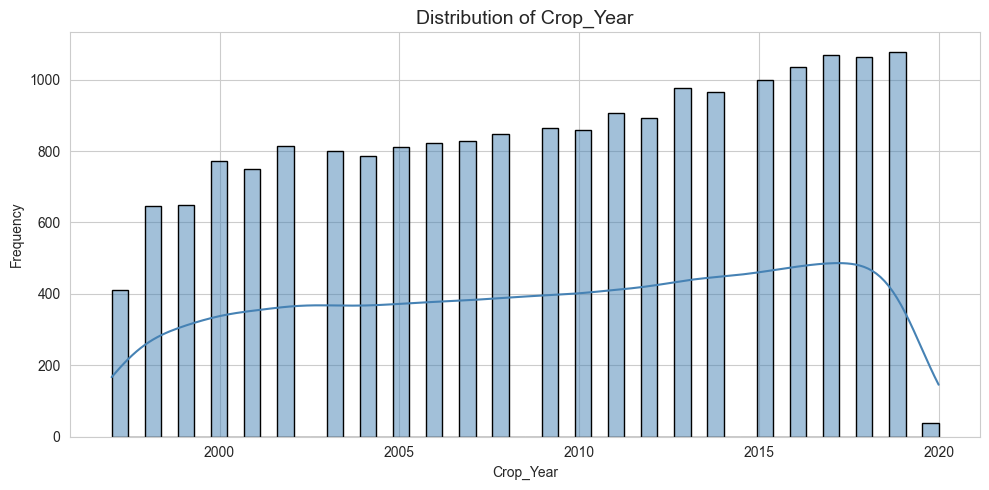

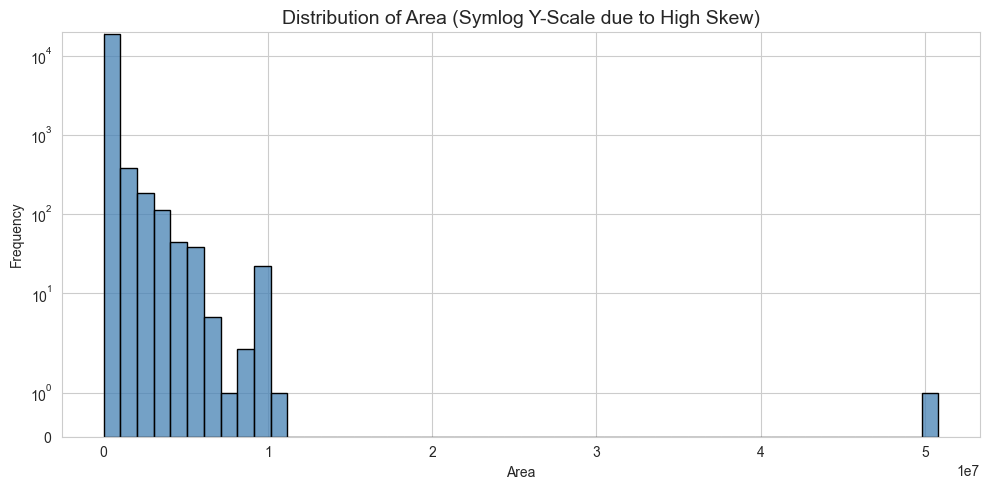

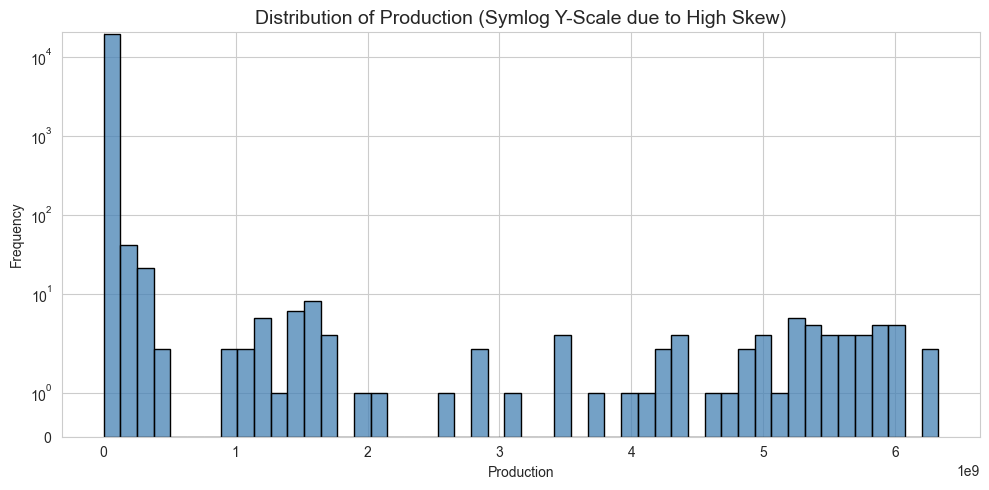

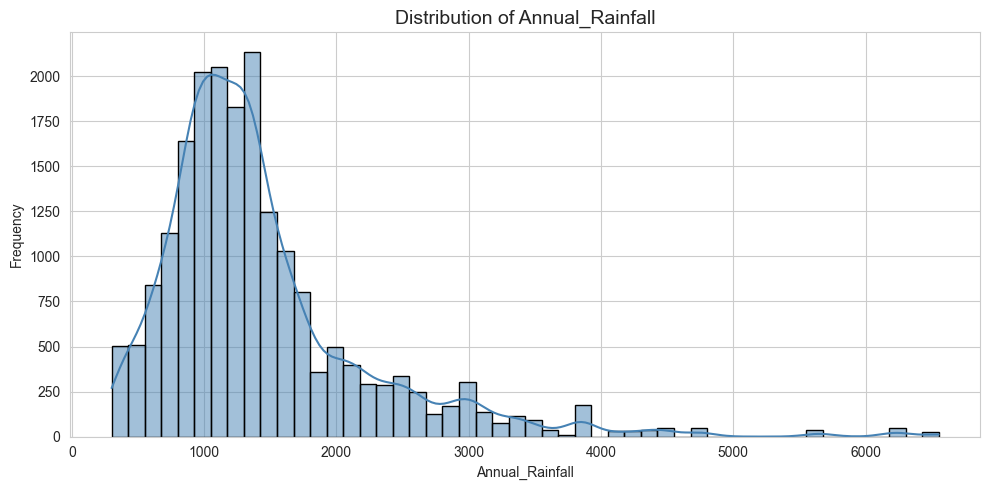

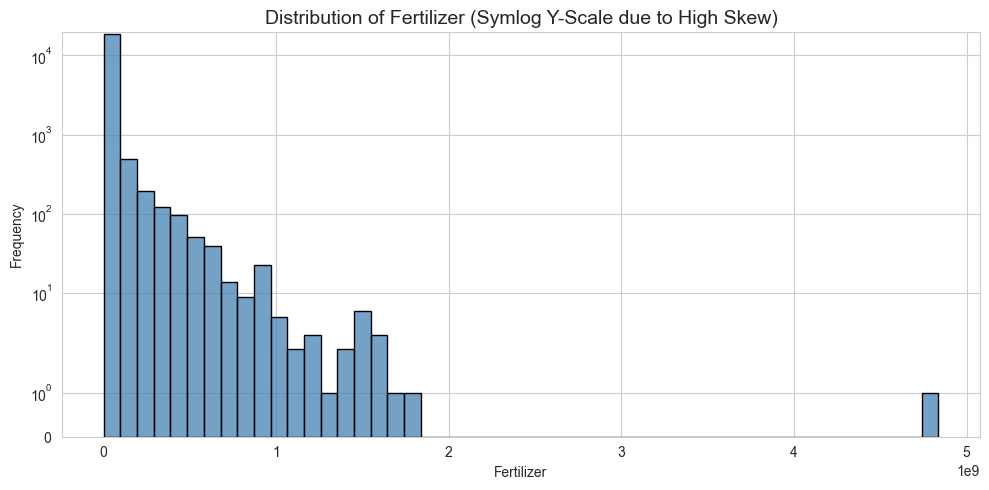

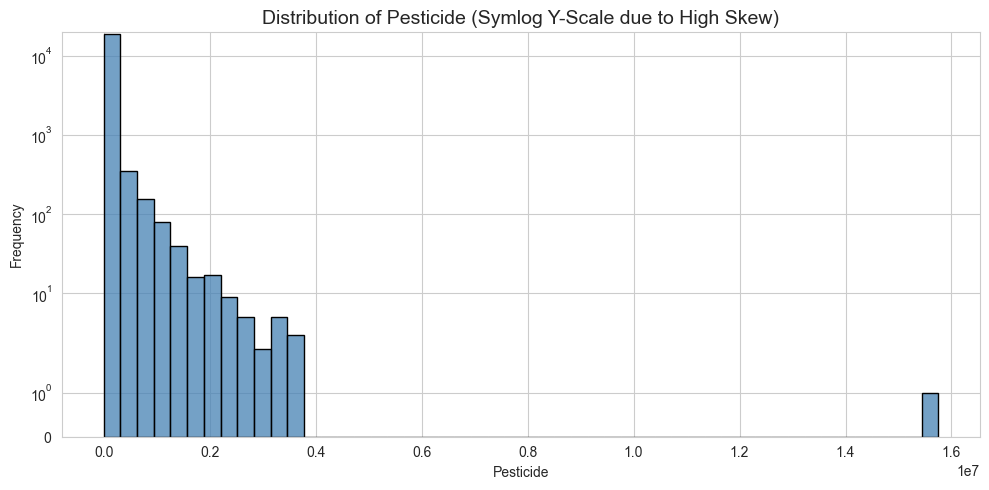

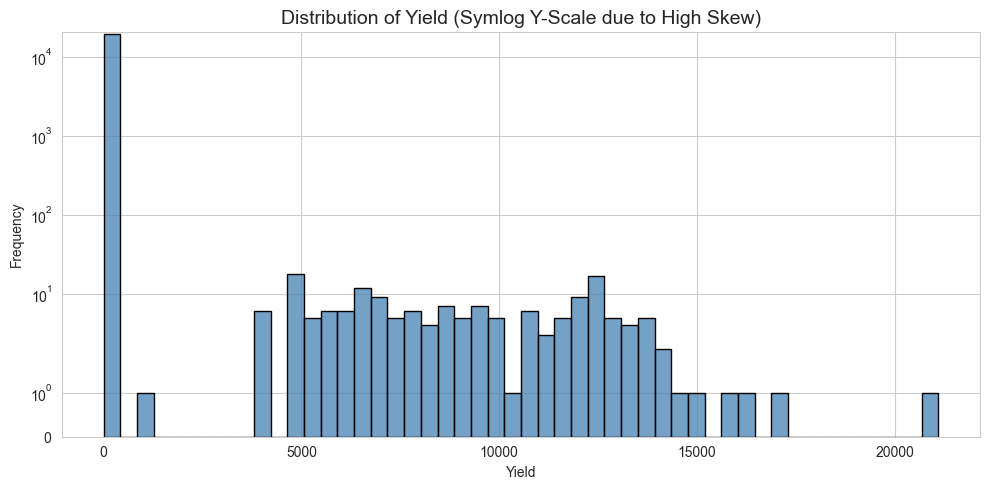

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    plt.figure(figsize=(10, 5))
    if abs(df[col].skew()) > 3:
        # Using a log scale on the Y-axis here so the extreme outliers don't hide the main part of the data distribution
        sns.histplot(df[col], bins=50, color='steelblue', edgecolor='black')
        plt.yscale('symlog')
        plt.title(f'Distribution of {col} (Symlog Y-Scale due to High Skew)', fontsize=14)
    else:
        sns.histplot(df[col], bins=50, kde=True, color='steelblue', edgecolor='black')
        plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


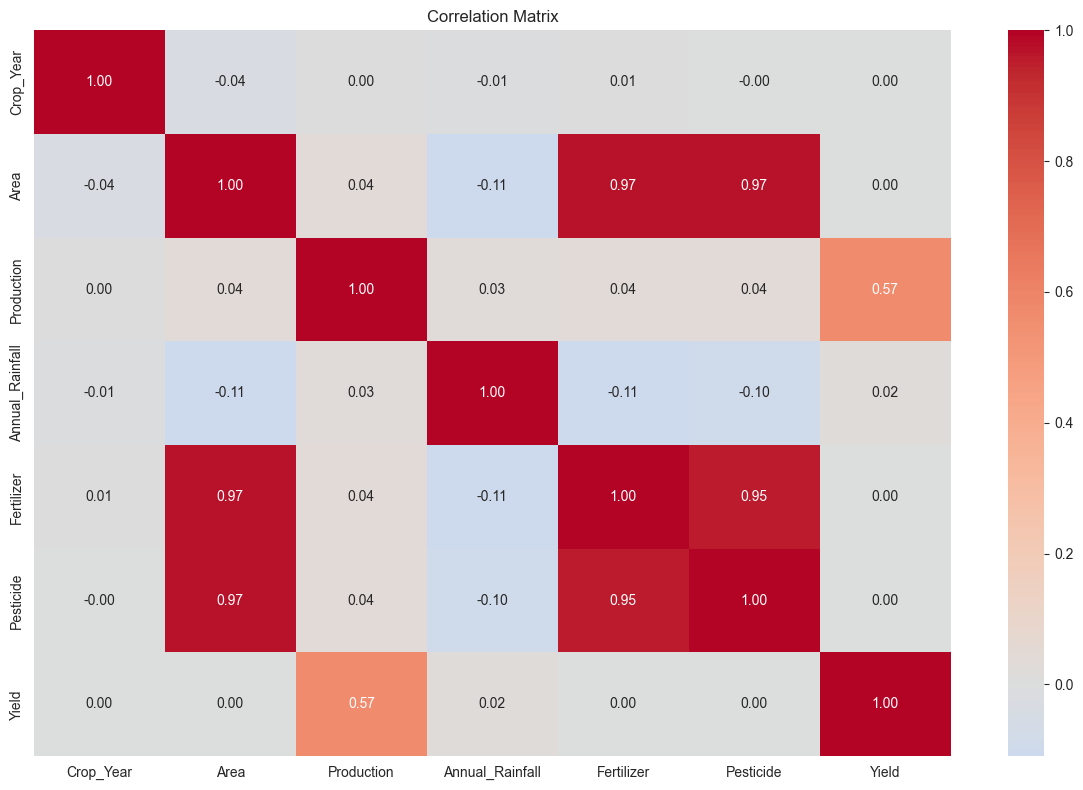

In [9]:
# TODO: Perform bivariate/multivariate analysis — explore relationships between features.
# Example: Correlation heatmap

# plt.figure(figsize=(12, 8))
# correlation_matrix = df.select_dtypes(include=np.number).corr()
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
# plt.title('Correlation Matrix')
# plt.tight_layout()
# plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df.select_dtypes(include=np.number).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Jotting down some early thoughts from the data exploration.
initial_insights = [
    "Production numbers vary a lot, which makes sense since some states have way more farmland than others.",
    "Rice and Wheat are definitely the stars of this dataset—plenty of records for both.",
    "I'm guessing that in years where there's less rain, the more 'resilient' crops will have much more stable yields."
]
for i, insight in enumerate(initial_insights, 1):
    print(f"{i}. {insight}")


1. Production numbers vary a lot, which makes sense since some states have way more farmland than others.
2. Rice and Wheat are definitely the stars of this dataset—plenty of records for both.
3. I'm guessing that in years where there's less rain, the more 'resilient' crops will have much more stable yields.


---
### Task 4: Verify Data Quality

Evaluate the completeness and correctness of the data. Check for problems that could affect the analysis:

- **Missing Values:** Identify columns with missing data, the volume, and patterns of missingness.
- **Duplicates:** Check for and report duplicate records.
- **Outliers:** Detect anomalous values using statistical methods or visualisations (box plots, z-scores).
- **Inconsistencies:** Look for data type mismatches, inconsistent formatting, or invalid entries.

**Instructions:** Systematically check for data quality issues and document your findings.

In [11]:
# TODO: Check for missing values.

# missing = df.isnull().sum()
# missing_pct = (df.isnull().sum() / len(df)) * 100
# missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
# missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
# print("=== Missing Values Report ===")
# print(missing_report)
# print(f"\nTotal columns with missing values: {len(missing_report)}")

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_report = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_report = missing_report[missing_report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print("=== Missing Values Report ===")
print(missing_report)
print(f"\nTotal columns with missing values: {len(missing_report)}")

=== Missing Values Report ===
Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []

Total columns with missing values: 0


In [12]:
# TODO: Check for duplicate records.

# duplicates = df.duplicated().sum()
# print(f"Number of duplicate rows: {duplicates}")
# if duplicates > 0:
#     print("\nSample of duplicate rows:")
#     print(df[df.duplicated(keep=False)].head(10))

duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("\nSample of duplicate rows:")
    print(df[df.duplicated(keep=False)].head(10))

Number of duplicate rows: 0


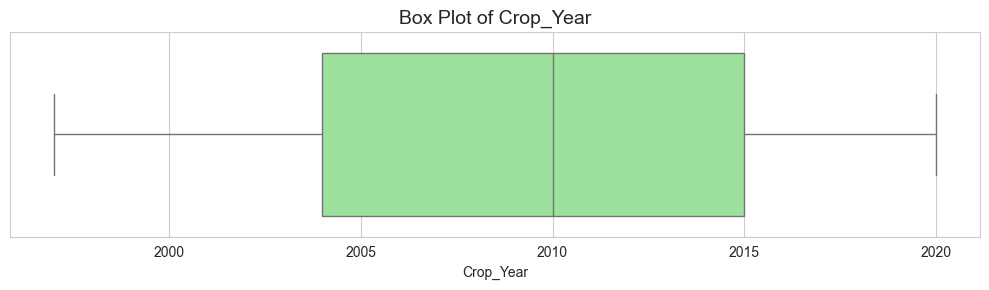

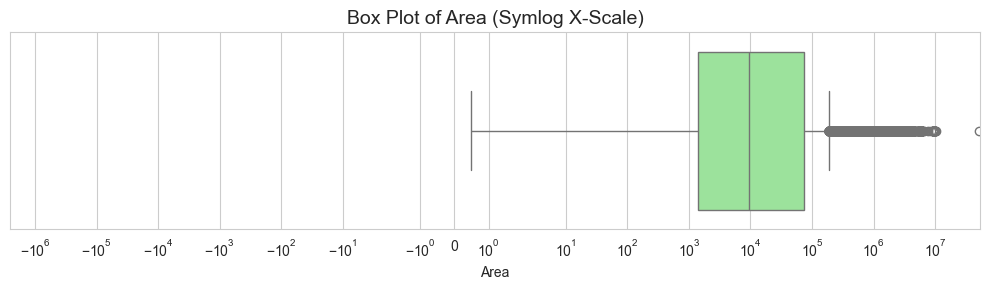

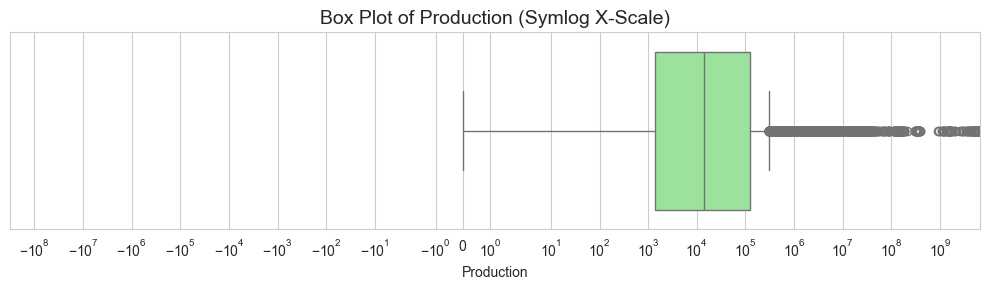

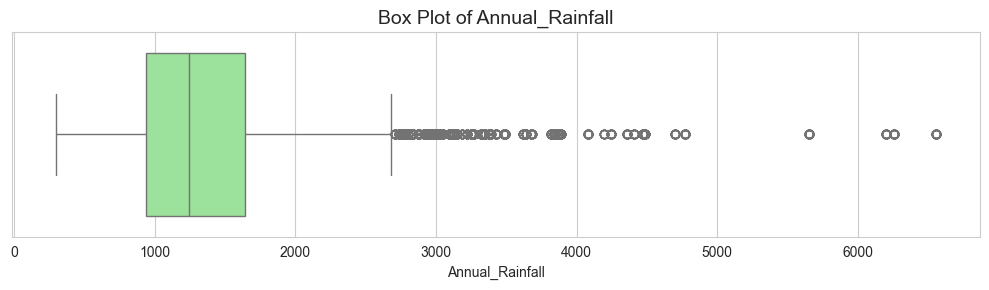

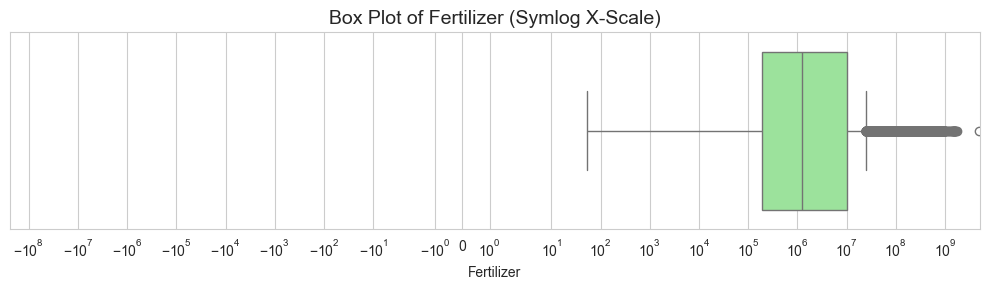

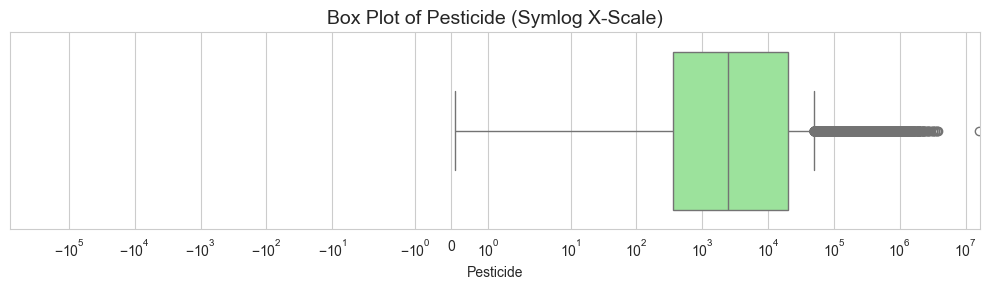

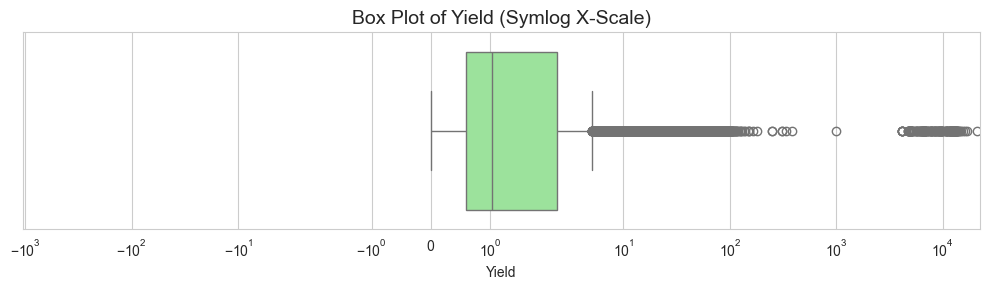

In [13]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
for col in numerical_cols:
    plt.figure(figsize=(10, 3))
    # I'm using horizontal box plots because they make it much easier to see names and values clearly
    sns.boxplot(x=df[col].dropna(), color='lightgreen')
    
    if abs(df[col].skew()) > 3:
        # Apply Symlog on X-axis so outliers don't crush the IQR box to 0
        plt.xscale('symlog')
        plt.title(f'Box Plot of {col} (Symlog X-Scale)', fontsize=14)
    else:
        plt.title(f'Box Plot of {col}', fontsize=14)
        
    plt.tight_layout()
    plt.show()
